In [1]:
#Standard House keeping
import numpy as np
import matplotlib.pyplot as plt
import socket
print(socket.gethostname())
import torch
from torch import nn
from torch.utils.data import TensorDataset,DataLoader, Dataset
print("cuda available?", torch.cuda.is_available())
import scipy.linalg as linalg
import matplotlib.pyplot as plt
print(f"NumPy:  {np.__version__}")
print(f"PyTorch: {torch.__version__}")
import os
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Dis-MacBook-Pro.local
cuda available? False
NumPy:  2.0.2
PyTorch: 2.8.0
Using mps device


In [ ]:
#eval setting
np.random.seed(7) #Generate different eval picture?
Neval = 3 #Set the number of eval 100*100*608 pictures
transient_toggle = True #Set fo false if no transients is desired

In [3]:
trans_scin_range = (0.01,0.2)
AGN_scin_range = (0.00005,0.2)  ## replicates the observed variability fractions in CHILES VERDES
varbins = np.array([0,0.02,0.1]) ## fractional brightness fluctuation standard deviation. 0.1 Corresponds to a 10% RMS flux density fluctuation
varprobs = np.array([136/185,33/185,16/185]) ## correspond probabilities. Must sum to 1

### LOAD IN THE VARIABILITY: ###

scinlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
#scinlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/scintillation_library.npz')['varlib']
varlib = np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/variation_library.npz')['varlib']
#varlib = np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/variation_library.npz')['varlib']
transientsdata = (np.load('/Users/dtian/Documents/Programming/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
#transientsdata = (np.load('/home/dtian/scratch/Di_Research/Di_codefromFir/TDE_afterglows/ISM_profile/JettedTDE_ISM1.npz')['data'])[:,:,20]
print(transientsdata.shape) 

(7000, 608)


In [4]:
def make_gaussian_heatmap(binary_target, sigma=2.0):
    """
    binary_target: (H, W) array with a few 1s at feature locations.
    returns:       (H, W) float heatmap, peaks = 1.0 at each feature.
    """
    H, W = binary_target.shape
    heatmap = np.zeros((H, W), dtype=np.float32)

    # locations of the 1s
    ys, xs = np.nonzero(binary_target)

    # precompute kernel radius (3 sigma covers ~99% of the blob)
    radius = int(np.ceil(3 * sigma))

    for cy, cx in zip(ys, xs):
        # bounds of the patch to write into (clipped to image edges)
        y0, y1 = max(0, cy - radius), min(H, cy + radius + 1)
        x0, x1 = max(0, cx - radius), min(W, cx + radius + 1)

        yy, xx = np.mgrid[y0:y1, x0:x1]
        g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * sigma ** 2))

        # max-combine so overlapping blobs stay <= 1
        heatmap[y0:y1, x0:x1] = np.maximum(heatmap[y0:y1, x0:x1], g)

    return heatmap
def gaussian2d(x,y,meanx,meany):

    FWHM = 5

    '''
    returns a 2d gaussian with the right shape
    '''

    return np.exp(-0.5*2.3**2*((x-meanx)**2+(y-meany)**2)/FWHM**2) # factor of 2.3 converts the FWHM to a standard deviation

def genbackground(xlen,ylen,tlen,Nbgnd,noiseamp=0.1):

    x = np.arange(xlen) ## x,y,t arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    #
    rng = np.random.default_rng(123)
    
    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    backgroundfield = np.zeros(noisefield.shape) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Nbgnd,2))

    for i in range(Nbgnd): ## for each background source

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen)) ## generate a uniform random map position

        bgfluxdensity = 10**(2*np.random.rand()-1) ## brightness, right now log-uniform between 0.1 and 10

        layer = bgfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1]) # add the map layer value

        ## apply intrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)

        randfloat = np.random.rand()
        
        if randfloat <= varprobs[0]:
            amp = varbins[0]
        elif randfloat <= varprobs[0]+varprobs[1]:
            amp = varbins[1]
        else:
            amp = varbins[2]
        
        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(AGN_scin_range[1]/AGN_scin_range[0]))*np.random.rand()+np.log10(AGN_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        backgroundfield += layer



    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return backgroundfield,noisefield,positions
        
def gentransients(xlen,ylen,tlen,Ntrans):
    '''
    Return  transient_field:    100*100*608 transient field
            positions:          Ntrans * 2 transient positions
            gaussian_transient_map 100*100 2d-gaussian position of the transient
    '''

    global transientsdata
    #np.random.seed(41)
    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)
    t = np.arange(tlen) 

    xx,yy,tt = np.meshgrid(x,y,t) ## create a grid of x,y positions to evaluate at

    transient_field = np.zeros((xlen,ylen,tlen)) ## array for the transient layer to be created in
    
    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    positions = np.zeros((Ntrans,2))
    transient_map = np.zeros((xlen, ylen))

    for i in range(Ntrans):

        x0.append(np.random.randint(xlen))
        y0.append(np.random.randint(ylen))

        while True:
            LCidx = np.random.randint(7000)
            LC = transientsdata[LCidx]
            if np.max(LC) != 0: break #This ensure np.max is no zero and eliminate Nan
        LC /= np.max(LC)
        transfluxdensity = 10**(np.random.rand()-0.5) ## right now log-uniform between 0.3 and 3 ## change as you see fit

        ## apply the shape of the lightcurve
        
        layer = transfluxdensity*gaussian2d(xx,yy,x0[-1],y0[-1])*LC[np.newaxis,np.newaxis,:tlen]

        ## apply extrinsic variability:

        idx = np.random.randint(2000)
        phase = np.random.randint(608)
        amp = 10**((np.log10(trans_scin_range[1]/trans_scin_range[0]))*np.random.rand()+np.log10(trans_scin_range[0]))
        #print(amp)

        layer*= 1+amp*(varlib[idx][phase:])[np.newaxis,np.newaxis,:tlen]

        transient_field += layer

        transient_map[y0[-1]][x0[-1]] = 1
    gaussian_transient_map = make_gaussian_heatmap(transient_map)
    positions[:,0] = np.array(x0)
    positions[:,1] = np.array(y0)

    return transient_field,positions,gaussian_transient_map


In [5]:
def genfields(Nfields=10, xlen=100, ylen=100, tlen=608, noiseamp=0.1, transient_toggle = True):
    '''
    Return: combined_field: Nfield * xlen * ylen * tlen, X input for NN
            target_maps:    Nfield * xlen * ylen, y for NN
            bgpositions:    Nfield * Nbgnd * 2, location of all background
            transientpositions: Nfield * Ntrans * 2, location of all transients

    '''
    combined_fields = np.empty((Nfields, xlen, ylen, tlen), dtype=np.float32)
    target_maps     = np.empty((Nfields, xlen, ylen),       dtype=np.float32)
    bgpositions, transientspositions = [], []

    for i in range(Nfields):
        print("Generating Image Index:", i)
        Nbgnd  = np.random.randint(1, 20)
        if(transient_toggle):
            Ntrans = np.random.randint(1, 10)
        else: 
            Ntrans = 0
        bg, noise, bgposition = genbackground(xlen, ylen, tlen, Nbgnd, noiseamp)
        transient, tpos, target_map = gentransients(xlen, ylen, tlen, Ntrans)

        combined_fields[i] = bg + noise + transient   
        target_maps[i]     = target_map
        bgpositions.append(bgposition)
        transientspositions.append(tpos)
    #bgpositions = np.array(bgpositions)
    #transientspositions = np.array(transientspositions)
    return combined_fields, target_maps, bgpositions, transientspositions

In [6]:
def normalize_data(data, eps=1e-8):
    mean = data.mean()
    std = data.std()
    return (data - mean) / (std + eps), mean, std

def convert_to_torch_data(data):
    data = torch.from_numpy(data)          
    data = data.squeeze(0)
    if data.dim() == 4:                    # NHWC -> NCHW
        data = data.permute(0, 3, 1, 2).contiguous()   
    data, mean, std = normalize_data(data) 
    return data, mean, std                 

In [7]:
class ResBlock(nn.Module):
    '''
    
    '''
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            #nn.ReLU(), Why breaks when I put an RELU here?
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x)) # This ensures when self.bloacl(x) spikes to negative, remains positive


class HeatmapNet(nn.Module):
    """
    Input:  (N, 608, 100, 100)
    Output: (N, 100, 100)
    """
    def __init__(self, tlen=608):
        super().__init__()
        # Encode
        self.stem = nn.Sequential(
            nn.Conv2d(tlen, 96, 7, padding=3), nn.BatchNorm2d(96), nn.ReLU(),
        )                                                  # (N, 96, 100, 100)
        self.enc1  = nn.Sequential(ResBlock(96), ResBlock(96))
        self.down1 = nn.MaxPool2d(2)                       # 50x50

        self.enc2  = nn.Sequential(
            nn.Conv2d(96, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192), ResBlock(192),
        )                                                  # (N, 192, 50, 50)
        self.down2 = nn.MaxPool2d(2)                       # (N, 192, 25, 25)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(192, 384, 3, padding=1), nn.BatchNorm2d(384), nn.ReLU(),
            ResBlock(384), ResBlock(384),
        )                                                  # (N, 384, 25, 25)

        #Decode
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) # (N, 384, 25, 25) -> (N, 384, 50, 50)
        self.dec2 = nn.Sequential(
            nn.Conv2d(384 + 192, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(),
            ResBlock(192),
        )                                                  
        self.up1  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False) #upsample from 50 to 100, (N, 384, 100, 100)
        self.dec1 = nn.Sequential(
            nn.Conv2d(192 + 96, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(),
            ResBlock(96),
        )                                                  

        self.head = nn.Conv2d(96, 1, 1)                    # 1-channel logits

    def forward(self, x):
        s  = self.stem(x)
        e1 = self.enc1(s)                       # 100x100
        e2 = self.enc2(self.down1(e1))          # 50x50
        b  = self.bottleneck(self.down2(e2))    # 25x25

        d2 = self.dec2(torch.cat([self.up2(b),  e2], dim=1))  # 50x50
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))  # 100x100
        return self.head(d1).squeeze(1)         # (N, 100, 100) 

In [8]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(dataloader)


def test_loop(dataloader, model, loss_fn):
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0
    all_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            all_preds.append(pred)

    test_loss /= num_batches
    all_preds = torch.cat(all_preds, dim=0)
    return all_preds, test_loss  

In [9]:
batch_size = 128 #Doesn't seem to matter when evaluating
model = HeatmapNet().to(device)
print(model)
loss_fn = nn.MSELoss()

HeatmapNet(
  (stem): Sequential(
    (0): Conv2d(608, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (enc1): Sequential(
    (0): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResBlock(
      (block): Sequential(
        (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [10]:

model = HeatmapNet(tlen=608).to(device)          # same architecture
model.load_state_dict(torch.load("/Users/dtian/Documents/Programming/NSERC 2026/NSERC_2026/CNN_Weights/best_weight.pth", map_location=device))
model.eval()                                      # set to inference mode
X_eval, y_eval, bgspositions_eval, transientspositions_eval= genfields(Nfields=Neval, transient_toggle=transient_toggle)
np.save("/Users/dtian/Documents/Programming/NSERC 2026/NSERC_2026/CNN_Weights/X_eval.npy", X_eval)
np.save("/Users/dtian/Documents/Programming/NSERC 2026/NSERC_2026/CNN_Weights/y_eval.npy", y_eval)
np.savez("/Users/dtian/Documents/Programming/NSERC 2026/NSERC_2026/CNN_Weights/bgspositions_eval.npy", *bgspositions_eval)
np.savez("/Users/dtian/Documents/Programming/NSERC 2026/NSERC_2026/CNN_Weights/transientspositions_eval.npy", *transientspositions_eval)
X_eval,_,_ = convert_to_torch_data(X_eval)
y_eval,_,_ = convert_to_torch_data(y_eval)

new_dataset = TensorDataset(X_eval, y_eval)
new_dataloader = DataLoader(new_dataset, batch_size=batch_size)

preds, loss = test_loop(new_dataloader, model, loss_fn)

#true_values = torch.cat([y for _, y in new_dataloader], dim=0)
y_train_mean = torch.tensor(0.0110)
y_train_std = torch.tensor(0.0741)
preds = y_train_mean + preds * y_train_std
preds = preds.cpu().numpy()
print(y_eval)
print(preds)


Generating Image Index: 0
Generating Image Index: 1
Generating Image Index: 2
Generating Image Index: 3
Generating Image Index: 4
Generating Image Index: 5
Generating Image Index: 6
tensor([[[-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         ...,
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863]],

        [[-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1863, -0.1863, -0.1863,  ..., -0.1863, -0.1863, -0.1863],
         ...,
         [-0.1218,  0.0125,  0.2907,  ..., -0.1863, -0.1863, -0.1863],
         [-0.1654, -0.1218, -0.0315,  ..., -0.1863, -0.1863, -0.1863],
       

0


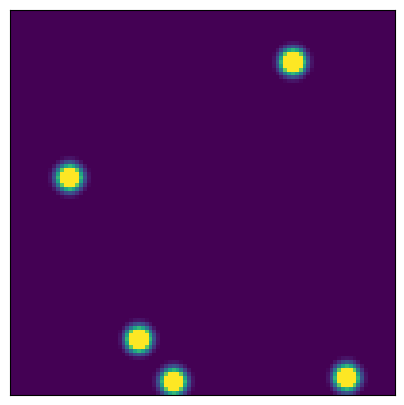

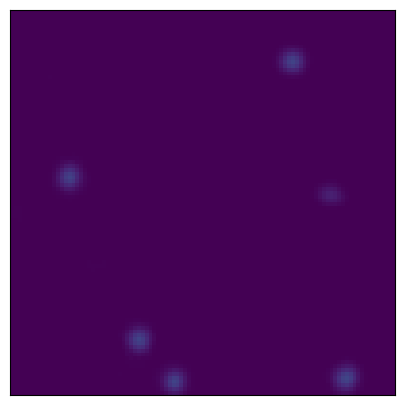

1


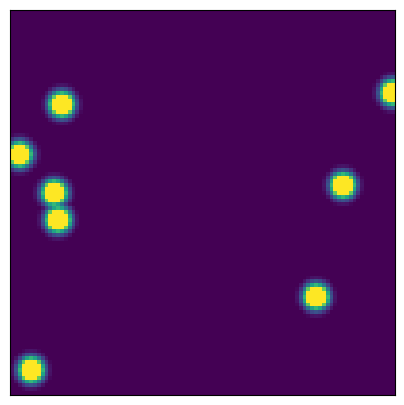

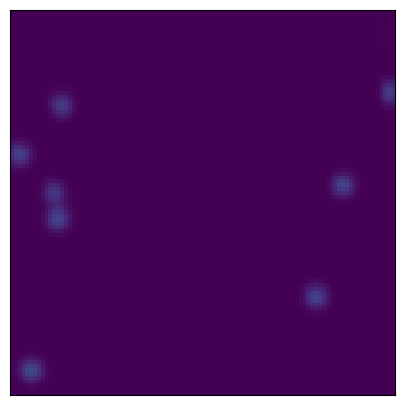

2


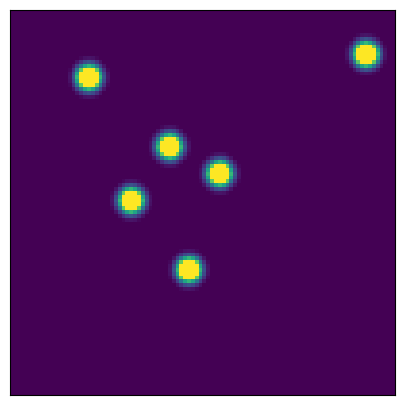

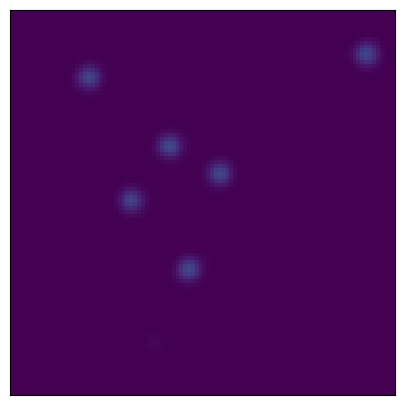

3


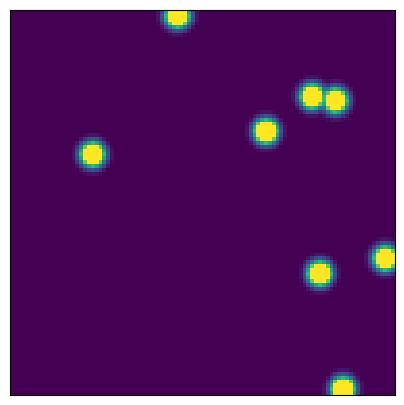

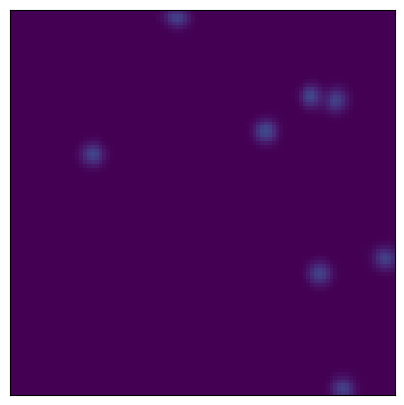

4


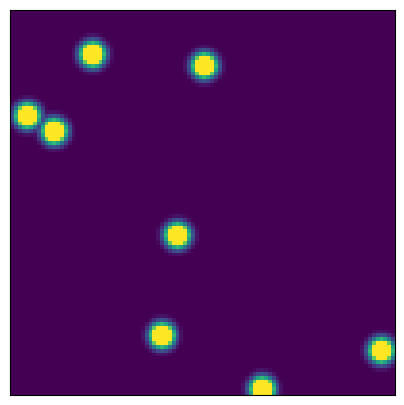

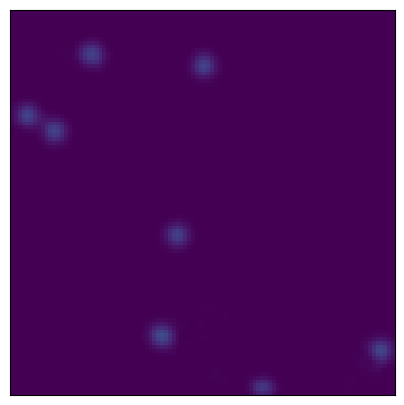

5


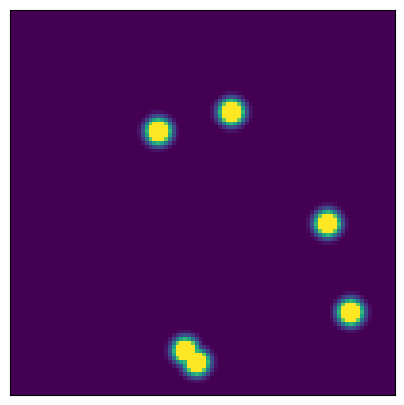

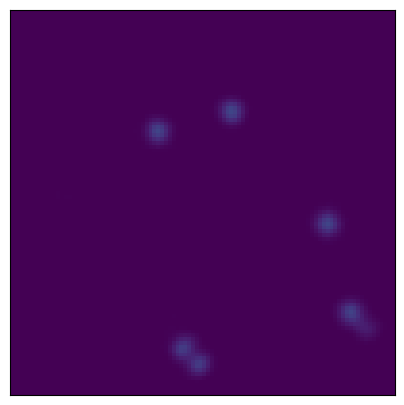

6


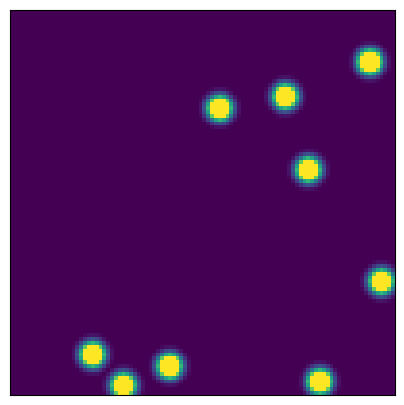

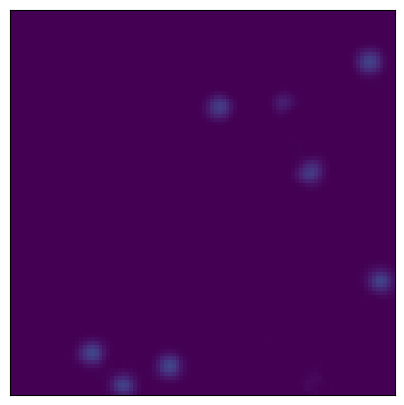

: 

In [ ]:
for i in range(Neval):
    print(i)
    plt.figure(figsize = (5,5))
    #f, axarr = plt.subplots(2,2)
    #axarr[i,0].imshow((y_eval[i]),vmax = 5,vmin = 0)
    plt.imshow((y_eval[i]),vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    #plt.show()
    #plt.close()
    
    plt.figure(figsize = (5,5))
    #axarr[i,1].imshow((preds[i]),vmax = 5,vmin = 0)
    plt.imshow((preds[i]),vmax = 5,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    plt.close()

In [ ]:
print(X_eval[0].shape)
for i in range(Neval):
    for frame in range(608):
        plt.figure(figsize = (100,100))
        plt.imshow((X_eval[0])[frame,:,:],vmax = 5,vmin = 0)
        plt.xticks([])
        plt.yticks([])
        plt.savefig('/Users/dtian/Documents/Programming/Images/pic_%d_frame_%d.png' %(i,frame))
        #plt.show()
        plt.close()

torch.Size([608, 100, 100])
